# Predicting 30-Day Hospital Readmission

### Patients with diabetes

**Technical presentation**  
Kavishna Ranmali Kalamba Arachchi  
25 September 2026

---

**Dataset:** Diabetes 130-US Hospitals for Years 1999–2008

## Problem framing

### Intended use
Rank patients at discharge so hospitals can prioritize beneficial transition-of-care support.

| Element | Definition |
|---|---|
| Task | Supervised binary classification |
| Positive class | Recorded inpatient readmission within 30 days |
| Negative class | Readmission after 30 days or no recorded readmission |
| Prediction time | Discharge from the first eligible encounter |
| Primary metric | Average Precision |

**Guardrail:** The model can support outreach allocation. But should not be used to deny care or determine treatment eligibility.

## Data and cohort construction

| Stage | Records |
|---|---:|
| Raw encounters | 101,766 |
| Unique patients | 71,518 |
| Analytic cohort | 69,973 |
| Training partition | 55,978 |
| Held-out test partition | 13,995 |

- Source: UCI Diabetes 130-US Hospitals dataset, 1999–2008
- One first eligible encounter per patient
- Hospice and death discharges excluded
- Stratified 80/20 split with identical 8.97% prevalence

In [1]:
#Reproducible cohort summary used in this presentation
import pandas as pd

cohort = pd.Series({
    "Raw encounters": 101_766,
    "Unique patients": 71_518,
    "Analytic cohort": 69_973,
    "Training": 55_978,
    "Held-out test": 13_995,
})
cohort.to_frame("Records")

,Records
Raw encounters,101766
Unique patients,71518
Analytic cohort,69973
Training,55978
Held-out test,13995


## Data quality and feature engineering

| Decision | Evidence and rationale |
|---|---|
| Drop weight | 96.07% missing in training |
| Retain laboratory Not_measured | Test absence is a meaningful process signal |
| Group ICD-9 codes | Reduces sparsity and improves interpretation |
| Bin prior utilization | Preserves stable gradients and limits sparse tails |
| Combine medication Up and Down | Reduces rare direction-specific levels |
| Remove drugs below 1% exposure | Training-only prevalence rule |
| Drop redundant medication count | Deterministic relationship with diabetesMed |

**Final representation:** 31 predictors, including 7 numeric and 24 categorical variables.

## Applied EDA

### Prior inpatient use provides the clearest utilization signal

Readmission rates:

| Prior-year use | No use | Any use | Difference |
|---|---:|---:|---:|
| Outpatient | 8.80% | 10.14% | +1.34 pts |
| Emergency | 8.72% | 12.22% | +3.50 pts |
| Inpatient | 8.11% | 15.46% | +7.35 pts |

Positive cases also had slightly longer stays and more laboratory procedures.

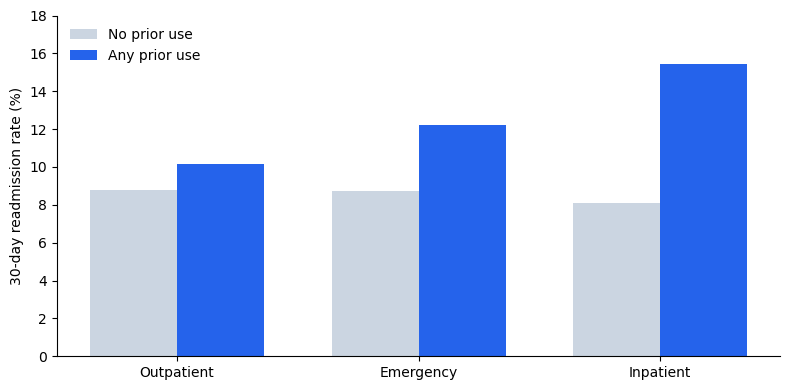

In [2]:
import matplotlib.pyplot as plt
import numpy as np

labels = ["Outpatient", "Emergency", "Inpatient"]
no_use = [8.80, 8.72, 8.11]
any_use = [10.14, 12.22, 15.46]
x = np.arange(len(labels))
width = 0.36
fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - width/2, no_use, width, label="No prior use", color="#CBD5E1")
ax.bar(x + width/2, any_use, width, label="Any prior use", color="#2563EB")
ax.set_xticks(x, labels)
ax.set_ylabel("30-day readmission rate (%)")
ax.set_ylim(0, 18)
ax.legend(frameon=False)
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

## Feature selection and dimensionality reduction

- Domain and filter rules removed identifiers, extreme-missingness fields, zero-variance variables, rare medications, and redundant features.
- Logistic regression tested embedded L1 coefficient-magnitude selection.
- The selector retained 72 of 129 encoded columns in the winning logistic specification.
- PCA on seven standardized numeric predictors found an encounter-intensity axis.
- The first two principal components did not visibly separate the outcome classes.

**Decision:** Retain the original predictors for interpretability and nonlinear modeling flexibility.

In [3]:
# Leading PC1 loadings reported by the fitted PCA
import pandas as pd

pd.Series({
    "num_medications": 0.556,
    "time_in_hospital": 0.512,
    "num_lab_procedures": 0.373,
    "num_procedures": 0.334,
    "number_diagnoses": 0.332,
    "num_med_changes": 0.259,
    "any_number_outpatient": 0.017,
}, name="PC1 loading").sort_values(ascending=False)

num_medications          0.556
time_in_hospital         0.512
num_lab_procedures       0.373
num_procedures           0.334
number_diagnoses         0.332
num_med_changes          0.259
any_number_outpatient    0.017
Name: PC1 loading, dtype: float64

## Model development

- Five-fold stratified cross-validation on the training partition
- Preprocessing learned inside every fold
- Logistic regression tuned with GridSearchCV
- Random forest and XGBoost tuned with RandomizedSearchCV
- Average Precision selected models
- Youden's J selected each operating threshold from out-of-fold predictions
- The test set remained untouched until final evaluation

**Caveat:** Hyperparameter selection and post-tuning OOF estimation used the same overall training data, so the OOF estimates may be mildly optimistic.

## XGBoost produced the strongest validation ranking

| Model | Average Precision | ROC-AUC | Recall | Precision | Balanced accuracy |
|---|---:|---:|---:|---:|---:|
| Dummy | 0.090 | 0.500 | 0.000 | 0.000 | 0.500 |
| Logistic regression | 0.160 | 0.645 | 0.588 | 0.133 | 0.605 |
| Random forest | 0.173 | 0.647 | 0.610 | 0.131 | 0.605 |
| **XGBoost** | **0.180** | **0.654** | **0.667** | 0.128 | **0.610** |

XGBoost improved Average Precision over random forest by 0.007. The gain was modest.

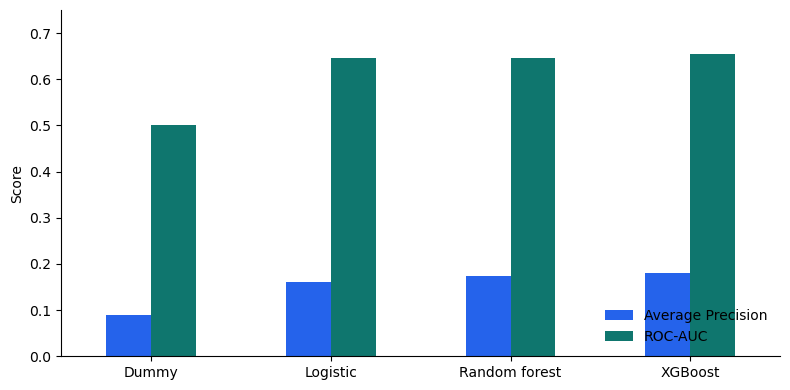

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

comparison = pd.DataFrame({
    "Average Precision": [0.090, 0.160, 0.173, 0.180],
    "ROC-AUC": [0.500, 0.645, 0.647, 0.654],
}, index=["Dummy", "Logistic", "Random forest", "XGBoost"])
ax = comparison.plot(kind="bar", figsize=(8, 4), color=["#2563EB", "#0F766E"], rot=0)
ax.set_ylim(0, 0.75)
ax.set_ylabel("Score")
ax.legend(frameon=False, loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

## Final held-out performance

### XGBoost at the fixed threshold of 0.0788

| Metric | Test result |
|---|---:|
| Average Precision | 0.183 |
| ROC-AUC | 0.653 |
| Recall | 0.666 |
| Precision | 0.128 |
| Specificity | 0.555 |
| Balanced accuracy | 0.610 |
| Brier loss | 0.079 |

The model identified **836 of 1,255** early readmissions. Its **6,511 alerts** included 5,675 false positives.

In [5]:
import pandas as pd

confusion_matrix = pd.DataFrame(
    [[7065, 5675], [419, 836]],
    index=["Actual negative", "Actual positive"],
    columns=["Predicted negative", "Predicted positive"],
)
confusion_matrix

,Predicted negative,Predicted positive
Actual negative,7065,5675
Actual positive,419,836


## Explainability

### Leading encoded features by mean absolute SHAP value

| Rank | Feature level | Mean absolute SHAP |
|---:|---|---:|
| 1 | Discharged to home | 0.219 |
| 2 | No prior inpatient utilization | 0.130 |
| 3 | Time in hospital | 0.071 |
| 4 | Primary diagnosis: circulatory | 0.053 |
| 5 | Age 50–59 | 0.049 |
| 6 | Number of laboratory procedures | 0.047 |
| 7 | Number of medications | 0.046 |

SHAP describes influence within the fitted model. It does not establish causation.

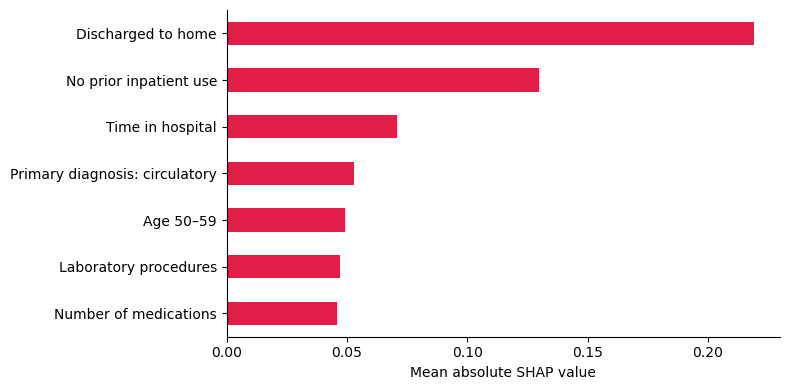

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

shap_values = pd.Series({
    "Discharged to home": 0.219,
    "No prior inpatient use": 0.130,
    "Time in hospital": 0.071,
    "Primary diagnosis: circulatory": 0.053,
    "Age 50–59": 0.049,
    "Laboratory procedures": 0.047,
    "Number of medications": 0.046,
}).sort_values()
ax = shap_values.plot(kind="barh", figsize=(8, 4), color="#E11D48")
ax.set_xlabel("Mean absolute SHAP value")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

## Bias and fairness audit

| Attribute | DP difference | DI ratio | TPR difference | FPR difference | Equalized-odds difference |
|---|---:|---:|---:|---:|---:|
| Race | 0.108 | 0.777 | 0.079 | 0.140 | 0.140 |
| Gender | 0.029 | 0.939 | 0.037 | 0.029 | 0.037 |
| **Age group** | **0.460** | **0.339** | **0.329** | **0.464** | **0.464** |

Age showed the largest disparity. Removing race, gender, and age did not consistently reduce subgroup gaps.

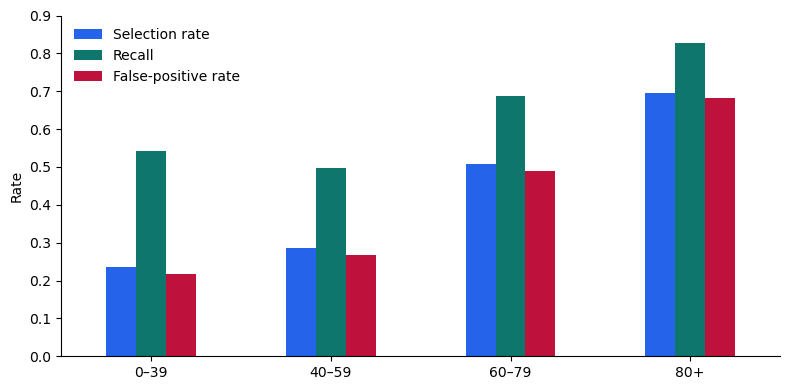

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

age = pd.DataFrame({
    "Selection rate": [0.236, 0.285, 0.508, 0.696],
    "Recall": [0.542, 0.498, 0.687, 0.827],
    "False-positive rate": [0.218, 0.268, 0.489, 0.682],
}, index=["0–39", "40–59", "60–79", "80+"])
ax = age.plot(kind="bar", figsize=(8, 4), color=["#2563EB", "#0F766E", "#BE123C"], rot=0)
ax.set_ylim(0, 0.9)
ax.set_ylabel("Rate")
ax.legend(frameon=False, loc="upper left")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()

## Conclusion

### The evidence supports a monitored prospective pilot

- XGBoost achieved the strongest tested ranking performance.
- The model identified about two-thirds of early readmissions but produced many false-positive alerts.
- Discharge setting, prior inpatient use, and encounter complexity drove predictions.
- Age-related disparities require explicit monitoring and mitigation.

**Key limitations:** historical data, possible missed external readmissions, discarded longitudinal history, and no socioeconomic variable.

**Required controls:** local validation, clinician review, capacity-based threshold selection, subgroup monitoring, drift review, and a documented escalation route.

**Recommended use:** Offer additional post-discharge support with clinical oversight.  
**Prohibited use:** Deny or reduce care, determine eligibility, or replace clinical judgment.

---

Data: UCI Machine Learning Repository, DOI 10.24432/C5230J  
Analysis source: attached Diabetes-readmission notebook